In [37]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import make_column_transformer,ColumnTransformer


In [5]:
rawdata = pd.read_excel(r'C:\Users\georg\Desktop\Bstorm Visual studio code\01 - Python_Full_Course\07_Machine_learning\Exercice ML-DM\5.Titanic\titanic3.xls')
rawdata

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [19]:
rawdata['embarked'].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [6]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


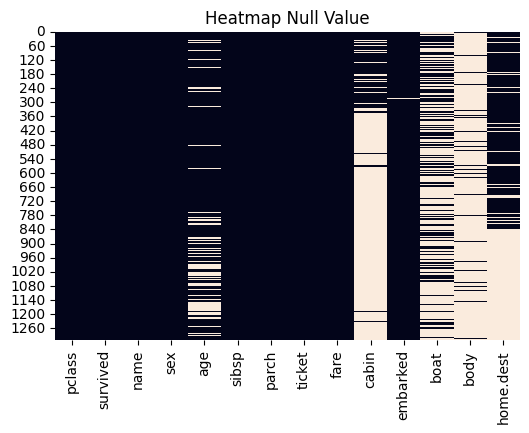

In [8]:
plt.figure(figsize=(6,4))
plt.title('Heatmap Null Value')
sns.heatmap(rawdata.isna(),cbar=False)
plt.show()

In [16]:
rawdata['cabin'].value_counts()

cabin
C23 C25 C27        6
B57 B59 B63 B66    5
G6                 5
D                  4
F4                 4
                  ..
F E46              1
F E57              1
F E69              1
E10                1
F38                1
Name: count, Length: 186, dtype: int64

In [17]:
rawdata['ticket'].value_counts()

ticket
CA. 2343      11
CA 2144        8
1601           8
PC 17608       7
347077         7
              ..
350406         1
349252         1
345767         1
359309         1
C.A. 49867     1
Name: count, Length: 939, dtype: int64

In [24]:
test = rawdata[['embarked']].dropna()
pd.get_dummies(test,drop_first=True)

,embarked_Q,embarked_S
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
1304,False,False
1305,False,False
1306,False,False
1307,False,False


In [32]:
data = rawdata.drop(columns=['boat','body','cabin','name','home.dest','ticket'])
data.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   fare      1308 non-null   float64
 7   embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 81.9+ KB


Imputation : Age(mean) , fare(mean) , embarked (mode)
Encodage : sex, embarked (OHencoder)


In [41]:
X = data.drop(columns=['survived'])
y = data['survived']
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Pipeline Time   

In [ ]:
age_fare_pipe = make_pipeline(SimpleImputer(strategy="mean"))
embarked_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder())

transformer =  make_column_transformer((age_fare_pipe,['age','fare']),
                                       (embarked_pipe,['sex','embarked']),
                                       remainder='passthrough')

finalpipe = make_pipeline(transformer,DecisionTreeClassifier())



In [42]:
finalpipe.fit(X_train,y_train)

c:\Users\georg\anaconda3\envs\Condaenv\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer())]),
                                                  ['age', 'fare']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['sex', 'embarked'])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [43]:
finalpipe.score(X_test,y_test)

0.7709923664122137

In [ ]:
finalpipe.get_params()

In [47]:
finalpipe[0]

ColumnTransformer(remainder='passthrough',
                  transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer())]),
                                 ['age', 'fare']),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder())]),
                                 ['sex', 'embarked'])])